In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib
sns.set_style("whitegrid")
RANDOM_STATE = 42

df=pd.read_csv("original2.csv")
print("Shape:", df.shape)


Shape: (1958, 16)


In [2]:

df.head()


,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,1734616,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,1419098,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,1797916,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,1805337,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,1351334,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


In [3]:

df.tail()


,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
1953,1991635,19,Female,Normal,Yes,African American,Normal,Adequate,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,NaN,Yes,0
1954,1528601,23,Female,Postmenopausal,Yes,Caucasian,Underweight,Low,Insufficient,Active,No,NaN,NaN,Corticosteroids,No,0
1955,1990957,34,Female,Postmenopausal,No,African American,Underweight,Low,Sufficient,Sedentary,No,NaN,Hyperthyroidism,NaN,No,0
1956,1779848,25,Male,Postmenopausal,No,African American,Normal,Low,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,Yes,0
1957,1282963,26,Female,Postmenopausal,No,African American,Underweight,Adequate,Sufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,0


In [4]:

print("Columns:", list(df.columns))


Columns: ['Id', 'Age', 'Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Alcohol Consumption', 'Medical Conditions', 'Medications', 'Prior Fractures', 'Osteoporosis']


In [5]:

df.dtypes


Id                     int64
Age                    int64
Gender                   str
Hormonal Changes         str
Family History           str
Race/Ethnicity           str
Body Weight              str
Calcium Intake           str
Vitamin D Intake         str
Physical Activity        str
Smoking                  str
Alcohol Consumption      str
Medical Conditions       str
Medications              str
Prior Fractures          str
Osteoporosis           int64
dtype: object

In [6]:

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1958.0,NaN,NaN,NaN,1549928.629724,261424.953731,1100064.0,1319163.0,1546027.5,1775870.5,1999676.0
Age,1958.0,NaN,NaN,NaN,39.101124,21.355424,18.0,21.0,32.0,53.0,90.0
Gender,1958,2,Male,992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hormonal Changes,1958,2,Normal,981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Family History,1958,2,No,998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Race/Ethnicity,1958,3,African American,681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Body Weight,1958,2,Normal,1027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Calcium Intake,1958,2,Low,1004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vitamin D Intake,1958,2,Sufficient,1011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Physical Activity,1958,2,Active,1021,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:

print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [8]:
df.drop(columns=['Id'],inplace=True)
print("Remaining columns:", list(df.columns))


Remaining columns: ['Age', 'Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Alcohol Consumption', 'Medical Conditions', 'Medications', 'Prior Fractures', 'Osteoporosis']


In [9]:
df.columns=df.columns.str.replace(' ','_')
df.columns=df.columns.str.lower()

In [10]:
df.isnull().sum()

age                      0
gender                   0
hormonal_changes         0
family_history           0
race/ethnicity           0
body_weight              0
calcium_intake           0
vitamin_d_intake         0
physical_activity        0
smoking                  0
alcohol_consumption    988
medical_conditions     647
medications            985
prior_fractures          0
osteoporosis             0
dtype: int64

In [11]:
df['alcohol_consumption'].unique()

<StringArray>
['Moderate', nan]
Length: 2, dtype: str

In [12]:
df['alcohol_consumption'] = df['alcohol_consumption'].replace({
    'Moderate': 'yes', 
    np.nan: 'no'
})

In [13]:
df['alcohol_consumption'].unique()

<StringArray>
['yes', 'no']
Length: 2, dtype: str

In [14]:
df['medical_conditions'] = df['medical_conditions'].replace({
    np.nan: 'healthy'
})

In [15]:
df['medications'].unique()

<StringArray>
['Corticosteroids', nan]
Length: 2, dtype: str

In [16]:
df['medications'] = df['medications'].replace({
    'Corticosteroids': 'yes', 
    np.nan: 'no'
})

In [17]:
df.isnull().sum()

age                    0
gender                 0
hormonal_changes       0
family_history         0
race/ethnicity         0
body_weight            0
calcium_intake         0
vitamin_d_intake       0
physical_activity      0
smoking                0
alcohol_consumption    0
medical_conditions     0
medications            0
prior_fractures        0
osteoporosis           0
dtype: int64

In [18]:

df.duplicated().sum()


np.int64(4)

In [19]:

df=df.drop_duplicates().reset_index(drop=True)

## 5. Data Type Correction

In [20]:

print(df.dtypes)
# Age is already a proper integer. All other feature columns are categorical strings
# and the target is already a clean 0/1 integer -- no coercion needed.
cat_cols = [c for c in df.columns if c not in ("Age", "Osteoporosis")]
for c in cat_cols:
    df[c] = df[c].astype("category")
print("\nCategorical columns cast to 'category' dtype:", cat_cols)


age                    int64
gender                   str
hormonal_changes         str
family_history           str
race/ethnicity           str
body_weight              str
calcium_intake           str
vitamin_d_intake         str
physical_activity        str
smoking                  str
alcohol_consumption      str
medical_conditions       str
medications              str
prior_fractures          str
osteoporosis           int64
dtype: object

Categorical columns cast to 'category' dtype: ['age', 'gender', 'hormonal_changes', 'family_history', 'race/ethnicity', 'body_weight', 'calcium_intake', 'vitamin_d_intake', 'physical_activity', 'smoking', 'alcohol_consumption', 'medical_conditions', 'medications', 'prior_fractures', 'osteoporosis']


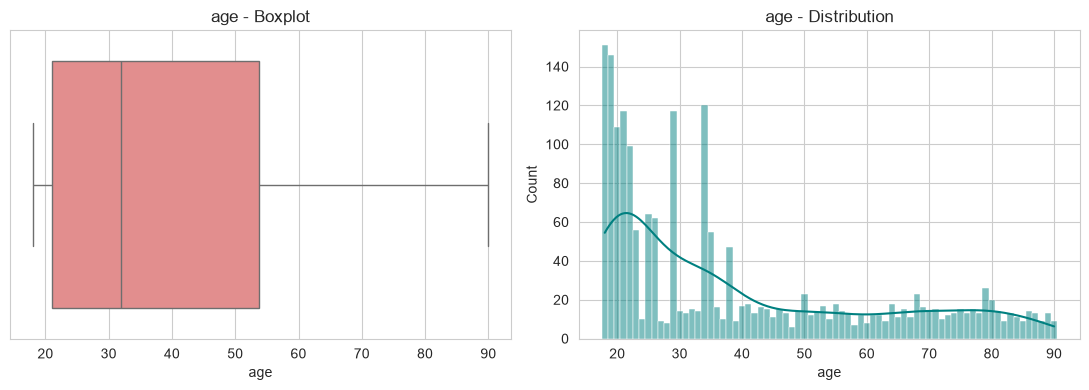

In [21]:

fig,axes=plt.subplots(1,2,figsize=(11, 4))
sns.boxplot(x=df["age"], ax=axes[0], color="lightcoral")
axes[0].set_title("age - Boxplot")
sns.histplot(df["age"], kde=True, ax=axes[1], color="teal")
axes[1].set_title("age - Distribution")
plt.tight_layout()
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_10180\3297088761.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="osteoporosis", data=df, palette="Set2")


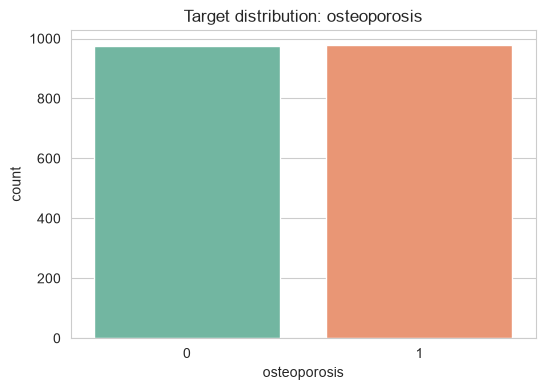

osteoporosis
1    0.501
0    0.499
Name: proportion, dtype: float64


In [22]:

plt.figure(figsize=(6, 4))
sns.countplot(x="osteoporosis", data=df, palette="Set2")
plt.title("Target distribution: osteoporosis")
plt.show()
print(df["osteoporosis"].value_counts(normalize=True).round(3))


C:\Users\Dell\AppData\Local\Temp\ipykernel_10180\4110261478.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="osteoporosis", y="age", data=df, ax=axes[1], palette="pastel")


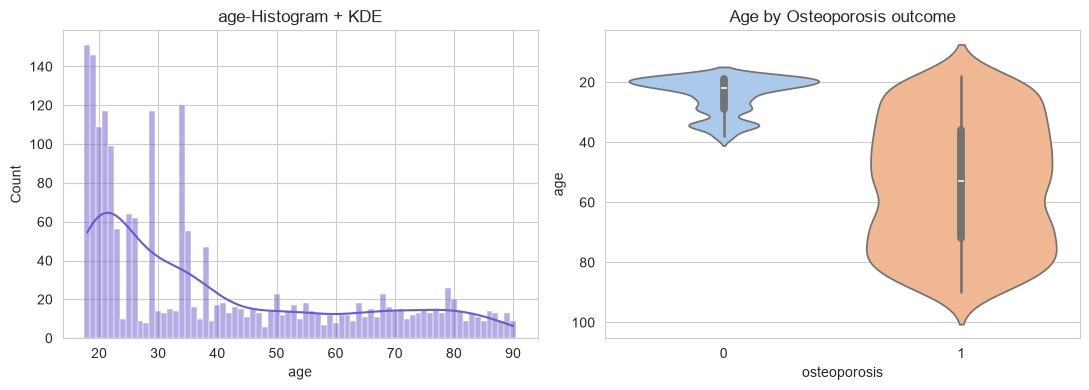

In [23]:

fig,axes=plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["age"],kde=True,ax=axes[0],color="slateblue")
axes[0].set_title("age-Histogram + KDE")
sns.violinplot(x="osteoporosis", y="age", data=df, ax=axes[1], palette="pastel")
axes[1].set_title("Age by Osteoporosis outcome")
plt.tight_layout()
plt.show()


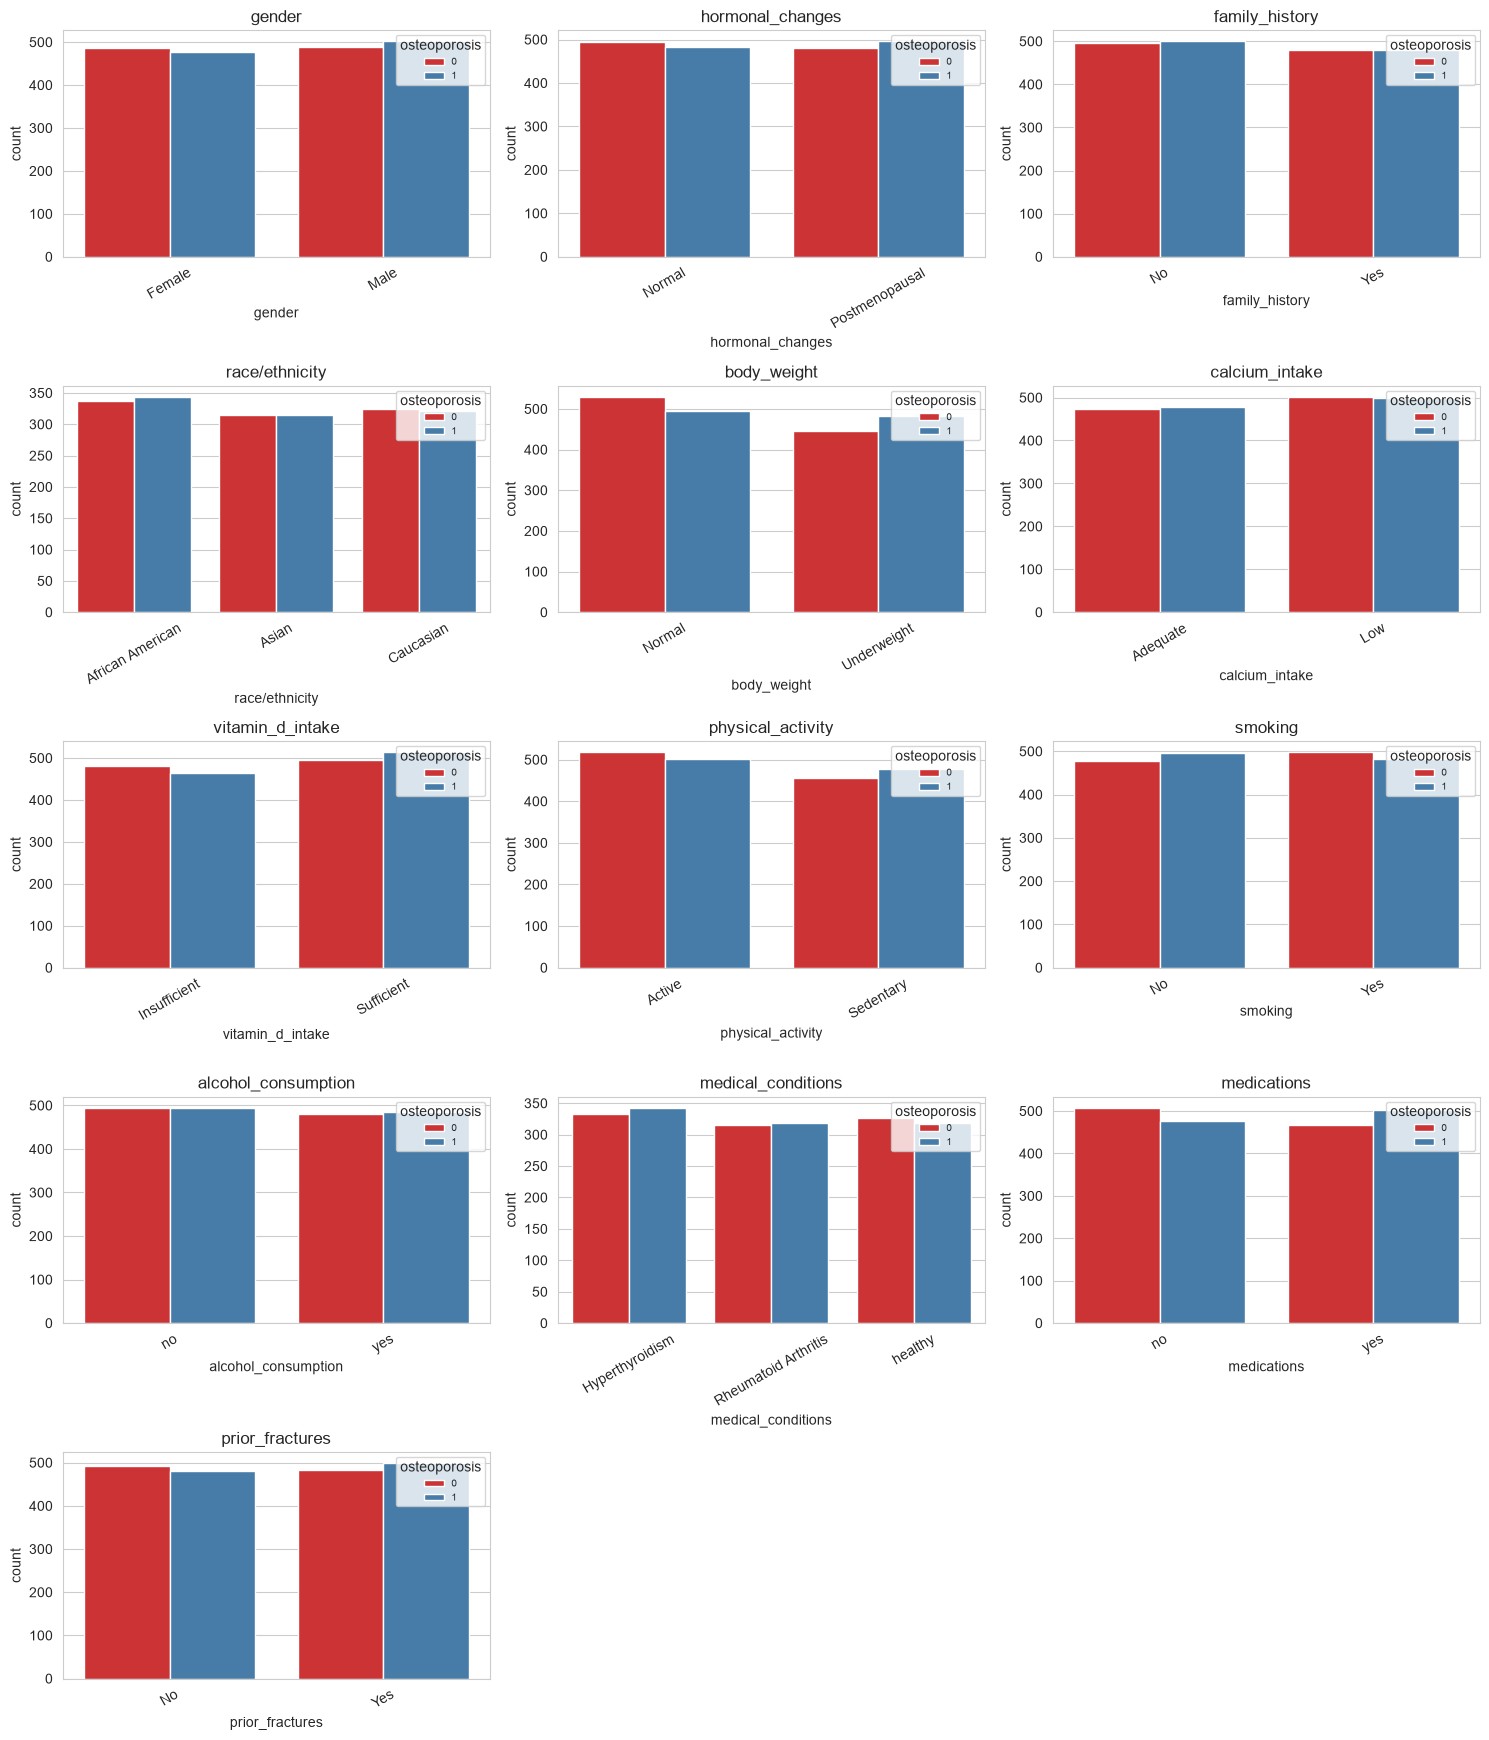

In [24]:

cat_features=[c for c in df.columns if c not in ("age","osteoporosis")]
n=len(cat_features)
ncols=3
nrows=int(np.ceil(n / ncols))
fig,axes=plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes=axes.flatten()
for i, col in enumerate(cat_features):
    sns.countplot(x=col,hue="osteoporosis", data=df, ax=axes[i], palette="Set1")
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title="osteoporosis", fontsize=7)
for j in range(len(cat_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


In [25]:


def cramers_v(col):
    ct=pd.crosstab(df[col], df["osteoporosis"])
    chi2=stats.chi2_contingency(ct)[0]
    n=ct.sum().sum()
    r,k=ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

assoc=pd.Series({c: cramers_v(c) for c in cat_features}).sort_values(ascending=False)
assoc


body_weight            0.035972
medications            0.033792
physical_activity      0.018529
smoking                0.016385
vitamin_d_intake       0.016318
hormonal_changes       0.013308
prior_fractures        0.013296
medical_conditions     0.011961
gender                 0.010207
race/ethnicity         0.006307
calcium_intake         0.003124
alcohol_consumption    0.003094
family_history         0.000984
dtype: float64

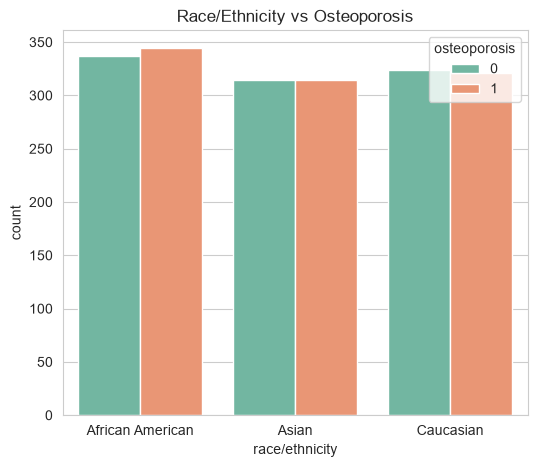

In [26]:

plt.figure(figsize=(6, 5))
sns.countplot(x="race/ethnicity", hue="osteoporosis", data=df, palette="Set2")
plt.title("Race/Ethnicity vs Osteoporosis")
plt.show()


In [27]:

from sklearn.preprocessing import LabelEncoder

binary_cols=[c for c in cat_features if df[c].nunique() == 2]
multi_cols=[c for c in cat_features if df[c].nunique() > 2]
label_encoders = {}
for col in binary_cols:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col].astype(str))
    label_encoders[col]=le
    print(f"{col}: {list(le.classes_)} -> {list(range(len(le.classes_)))}")


gender: ['Female', 'Male'] -> [0, 1]
hormonal_changes: ['Normal', 'Postmenopausal'] -> [0, 1]
family_history: ['No', 'Yes'] -> [0, 1]
body_weight: ['Normal', 'Underweight'] -> [0, 1]
calcium_intake: ['Adequate', 'Low'] -> [0, 1]
vitamin_d_intake: ['Insufficient', 'Sufficient'] -> [0, 1]
physical_activity: ['Active', 'Sedentary'] -> [0, 1]
smoking: ['No', 'Yes'] -> [0, 1]
alcohol_consumption: ['no', 'yes'] -> [0, 1]
medications: ['no', 'yes'] -> [0, 1]
prior_fractures: ['No', 'Yes'] -> [0, 1]


In [28]:

df=pd.get_dummies(df, columns=multi_cols, drop_first=True)
df.columns=[c.replace("/", "_") for c in df.columns]
print("Shape after encoding:", df.shape)
df.head()


Shape after encoding: (1954, 17)


,age,gender,hormonal_changes,family_history,body_weight,calcium_intake,vitamin_d_intake,physical_activity,smoking,alcohol_consumption,medications,prior_fractures,osteoporosis,race_ethnicity_Asian,race_ethnicity_Caucasian,medical_conditions_Rheumatoid Arthritis,medical_conditions_healthy
0,69,0,0,1,1,1,1,1,1,1,1,1,1,True,False,True,False
1,32,0,0,1,1,1,1,1,0,0,0,1,1,True,False,False,True
2,89,0,1,0,0,0,1,0,0,1,1,0,1,False,True,False,False
3,78,0,0,0,1,0,0,1,1,0,1,0,1,False,True,True,False
4,38,1,1,1,0,1,1,0,1,0,0,1,1,False,False,True,False


In [29]:

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
df["age"]=scaler.fit_transform(df[["age"]])
df["age"].describe()


count    1.954000e+03
mean    -5.818160e-17
std      1.000256e+00
min     -9.892277e-01
25%     -8.487788e-01
50%     -3.337997e-01
75%      6.844546e-01
max      2.381545e+00
Name: age, dtype: float64

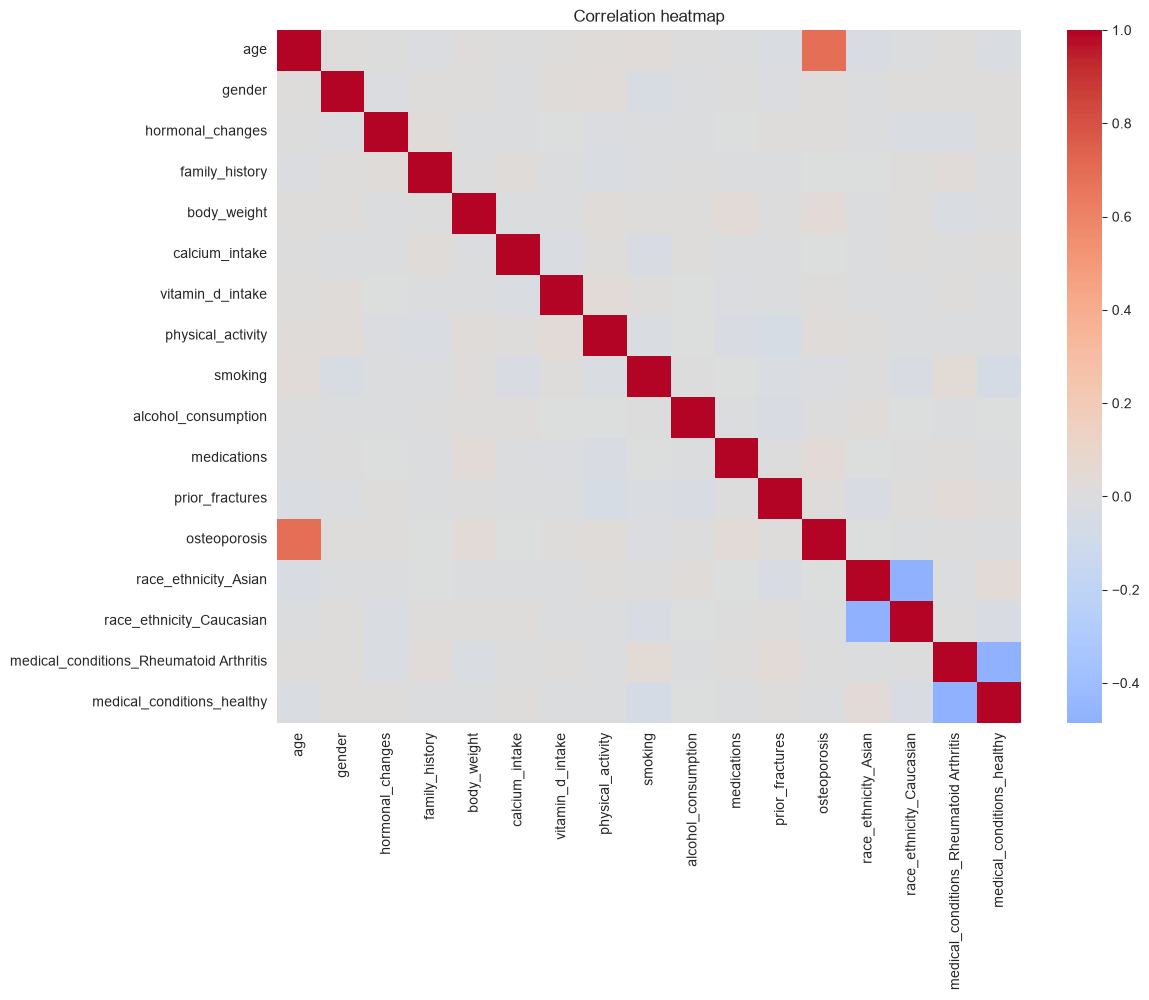

In [30]:

plt.figure(figsize=(12, 9))
corr=df.corr()
sns.heatmap(corr,cmap="coolwarm",center=0,annot=False)
plt.title("Correlation heatmap")
plt.show()


In [31]:

target_corr=corr["osteoporosis"].drop("osteoporosis").sort_values(key=abs, ascending=False)
target_corr


age                                        0.690972
body_weight                                0.036997
medications                                0.034816
physical_activity                          0.019553
smoking                                   -0.017409
vitamin_d_intake                           0.017342
hormonal_changes                           0.014332
prior_fractures                            0.014319
medical_conditions_healthy                -0.011232
gender                                     0.011231
race_ethnicity_Caucasian                  -0.004702
calcium_intake                            -0.004148
alcohol_consumption                        0.004117
family_history                            -0.002008
medical_conditions_Rheumatoid Arthritis    0.001864
race_ethnicity_Asian                      -0.001409
Name: osteoporosis, dtype: float64

In [32]:

feat_corr=df.drop(columns="osteoporosis").corr().abs()
upper=feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
high_corr_pairs=[(col, row, upper.loc[row, col]) for col in upper.columns for row in upper.index
                    if pd.notnull(upper.loc[row, col]) and upper.loc[row, col] > 0.8]
print("Highly correlated (>0.8) feature pairs:", high_corr_pairs if high_corr_pairs else "None found")


Highly correlated (>0.8) feature pairs: None found


In [33]:

from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

X = df.drop(columns="osteoporosis")
y = df["osteoporosis"]
feature_names = X.columns.tolist()


mi_scores = pd.Series(mutual_info_classif(X, y, random_state=RANDOM_STATE), index=feature_names).sort_values(ascending=False)


skb = SelectKBest(score_func=f_classif, k="all").fit(X, y)
f_scores = pd.Series(skb.scores_, index=feature_names).sort_values(ascending=False)
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
rfe = RFE(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), n_features_to_select=8)
rfe.fit(X, y)
rfe_selected = X.columns[rfe.support_].tolist()

comparison = pd.DataFrame({
    "mutual_info_rank": mi_scores.rank(ascending=False),
    "f_score_rank": f_scores.rank(ascending=False),
    "rf_importance_rank": rf_importance.rank(ascending=False),
}).round(1)
comparison["avg_rank"] = comparison.mean(axis=1)
comparison = comparison.sort_values("avg_rank")
comparison


,mutual_info_rank,f_score_rank,rf_importance_rank,avg_rank
age,1.0,1.0,1.0,1.000000
medications,4.0,3.0,7.0,4.666667
physical_activity,3.0,4.0,8.0,5.000000
smoking,2.0,5.0,11.0,6.000000
vitamin_d_intake,7.0,6.0,10.0,7.666667
alcohol_consumption,5.0,13.0,5.0,7.666667
hormonal_changes,12.0,7.0,4.0,7.666667
gender,12.0,10.0,2.0,8.000000
body_weight,12.0,2.0,12.0,8.666667
calcium_intake,12.0,12.0,3.0,9.000000


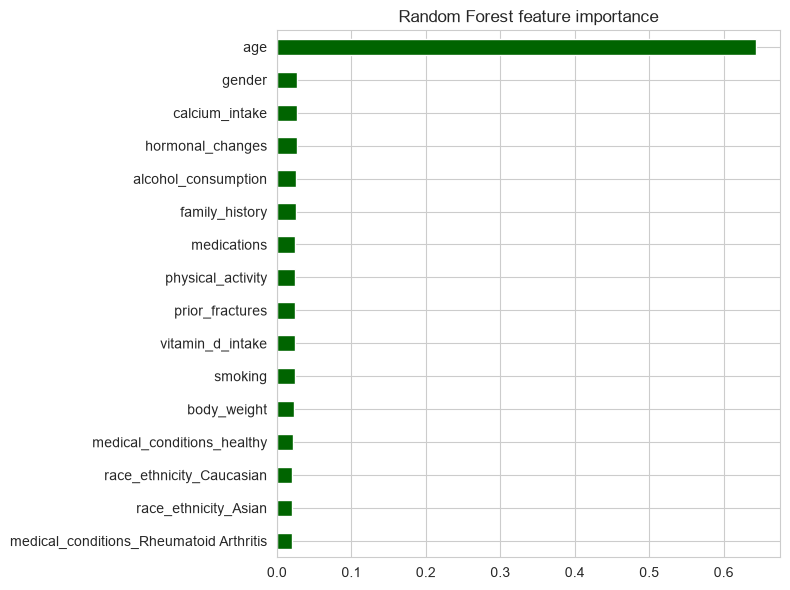

RFE-selected (top 8, logistic regression): ['age', 'vitamin_d_intake', 'smoking', 'medications', 'prior_fractures', 'race_ethnicity_Asian', 'race_ethnicity_Caucasian', 'medical_conditions_Rheumatoid Arthritis']


In [34]:

plt.figure(figsize=(8, 6))
rf_importance.sort_values().plot(kind="barh", color="darkgreen")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

print("RFE-selected (top 8, logistic regression):", rfe_selected)


In [35]:


from sklearn.linear_model import LogisticRegression as LRL1
lasso_lr = LRL1(penalty="l1", solver="liblinear", C=0.5, random_state=RANDOM_STATE)
lasso_lr.fit(X, y)
lasso_coef = pd.Series(lasso_lr.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)
print("Features with non-zero L1 coefficient:", lasso_coef[lasso_coef != 0].index.tolist())
lasso_coef


Features with non-zero L1 coefficient: ['age', 'medications', 'smoking', 'prior_fractures', 'race_ethnicity_Asian', 'medical_conditions_Rheumatoid Arthritis', 'vitamin_d_intake', 'body_weight', 'physical_activity', 'race_ethnicity_Caucasian', 'hormonal_changes', 'medical_conditions_healthy']


d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\osteoporosis\osteoporosis\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


age                                        3.287232
medications                                0.291385
smoking                                   -0.185012
prior_fractures                            0.179117
race_ethnicity_Asian                       0.140530
medical_conditions_Rheumatoid Arthritis   -0.104989
vitamin_d_intake                           0.076079
body_weight                                0.069772
physical_activity                          0.065208
race_ethnicity_Caucasian                   0.055677
hormonal_changes                           0.031261
medical_conditions_healthy                 0.022062
calcium_intake                             0.000000
family_history                             0.000000
gender                                     0.000000
alcohol_consumption                        0.000000
dtype: float64

In [36]:

SELECTED_FEATURES = comparison.head(10).index.tolist()
print("Final selected features:", SELECTED_FEATURES)


Final selected features: ['age', 'medications', 'physical_activity', 'smoking', 'vitamin_d_intake', 'alcohol_consumption', 'hormonal_changes', 'gender', 'body_weight', 'calcium_intake']


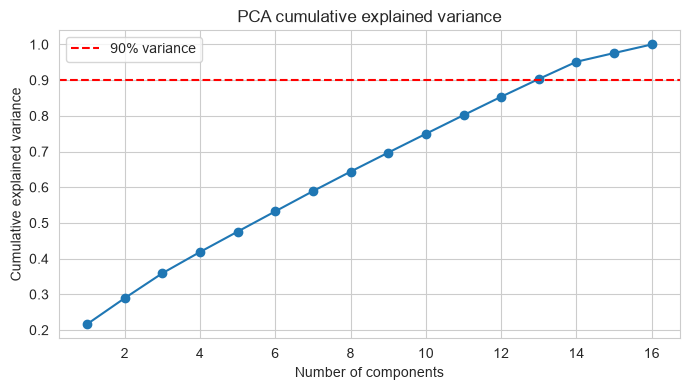

Components needed for 90% variance: 13 out of 16 original features


In [37]:

from sklearn.decomposition import PCA

pca_full = PCA(random_state=RANDOM_STATE).fit(X)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.show()

n_components_90 = int(np.argmax(cum_var >= 0.90) + 1)
print(f"Components needed for 90% variance: {n_components_90} out of {X.shape[1]} original features")


In [38]:

final_df = df[SELECTED_FEATURES + ["osteoporosis"]].copy()
print("Final shape:", final_df.shape)
print("Final columns:", list(final_df.columns))
print("\nTarget distribution:\n", final_df["osteoporosis"].value_counts())

final_df.to_csv("cleaned_osteoporosis_dataset.csv", index=False)
print("\nSaved -> cleaned_osteoporosis_dataset.csv")


Final shape: (1954, 11)
Final columns: ['age', 'medications', 'physical_activity', 'smoking', 'vitamin_d_intake', 'alcohol_consumption', 'hormonal_changes', 'gender', 'body_weight', 'calcium_intake', 'osteoporosis']

Target distribution:
 osteoporosis
1    979
0    975
Name: count, dtype: int64

Saved -> cleaned_osteoporosis_dataset.csv


In [39]:

joblib.dump(scaler, "scaler.joblib")
print("Saved -> scaler.joblib")

joblib.dump(label_encoders, "encoders.joblib")
print("Saved -> encoders.joblib")

joblib.dump(SELECTED_FEATURES, "feature_names.joblib")
print("Saved -> feature_names.joblib")

joblib.dump(multi_cols, "onehot_source_columns.joblib")
print("Saved -> onehot_source_columns.joblib (columns that were one-hot encoded, needed to replicate encoding on new data)")

Saved -> scaler.joblib
Saved -> encoders.joblib
Saved -> feature_names.joblib
Saved -> onehot_source_columns.joblib (columns that were one-hot encoded, needed to replicate encoding on new data)
